In [10]:
!pip install torch numpy matplotlib sentence-transformers requests

Imports

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import requests
from collections import deque
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

Models, buffer, noise, and DDPG agent

In [12]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim), nn.Tanh()
        )
    def forward(self, state):
        return self.net(state)

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, s_, done):
        self.buffer.append((s, a, r, s_, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(states),
            torch.FloatTensor(actions),
            torch.FloatTensor(rewards).unsqueeze(1),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones).unsqueeze(1)
        )
    def __len__(self):
        return len(self.buffer)

class OUNoise:
    def __init__(self, size, mu=0, theta=0.15, sigma=0.2):
        self.state = np.ones(size) * mu
        self.theta = theta
        self.sigma = sigma
        self.mu = mu
    def reset(self):
        self.state = np.ones_like(self.state) * self.mu
    def sample(self):
        dx = self.theta * (self.mu - self.state) + self.sigma * np.random.randn(len(self.state))
        self.state += dx
        return self.state

class DDPG:
    def __init__(self, state_dim, action_dim, gamma=0.99, tau=0.005, lr=1e-3):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.actor = Actor(state_dim, action_dim).to(self.device)
        self.actor_target = Actor(state_dim, action_dim).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic = Critic(state_dim, action_dim).to(self.device)
        self.critic_target = Critic(state_dim, action_dim).to(self.device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer()
        self.noise = OUNoise(action_dim)
        self.gamma = gamma
        self.tau = tau

    def select_action(self, state, add_noise=True):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        action = self.actor(state).cpu().data.numpy().flatten()
        if add_noise:
            action += self.noise.sample()
        return np.clip(action, -1, 1)

    def update(self, batch_size=64):
        if len(self.replay_buffer) < batch_size:
            return
        s, a, r, s_, d = self.replay_buffer.sample(batch_size)
        s, a, r, s_, d = s.to(self.device), a.to(self.device), r.to(self.device), s_.to(self.device), d.to(self.device)
        with torch.no_grad():
            target_actions = self.actor_target(s_)
            target_Q = self.critic_target(s_, target_actions)
            y = r + (1 - d) * self.gamma * target_Q
        current_Q = self.critic(s, a)
        critic_loss = nn.MSELoss()(current_Q, y)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        actor_loss = -self.critic(s, self.actor(s)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

Simulated Environment (training)

In [13]:
class DummyPromptEnv:
    def __init__(self):
        self.state_dim = 384  # based on sentence-transformers output
        self.action_dim = 3
        self.max_steps = 10
        self.step_count = 0
        self.state = np.random.randn(self.state_dim)

    def reset(self):
        self.step_count = 0
        self.state = np.random.randn(self.state_dim)
        return self.state

    def step(self, action):
        reward = -np.sum(action**2) + np.random.randn() * 0.1
        self.step_count += 1
        done = self.step_count >= self.max_steps
        next_state = np.random.randn(self.state_dim)
        return next_state, reward, done, {}


Sentence Embedding & Prompt Modifier

In [14]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def get_state_from_prompt(prompt):
    return embedder.encode(prompt)

def apply_action_to_prompt(prompt, action):
    tone = ["formal", "neutral", "casual"]
    detail = ["brief", "normal", "detailed"]
    tone_idx = int(np.clip((action[0] + 1) * 1.5, 0, 2))
    detail_idx = int(np.clip((action[1] + 1) * 1.5, 0, 2))
    prefix = f"Please answer in a {tone[tone_idx]} and {detail[detail_idx]} manner:\n"
    return prefix + prompt


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Groq API Call

In [30]:
def call_groq_api(prompt, api_key="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"):
    url = "https://api.groq.com/openai/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": "llama3-8b-8192",  # ✅ updated to supported model
        "messages": [{"role": "user", "content": prompt}]
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        if 'choices' not in data:
            return f"API Error: 'choices' key not in response. Full response: {data}"

        return data['choices'][0]['message']['content']

    except requests.exceptions.HTTPError as http_err:
        return f"HTTP error: {http_err} | Response: {response.text}"
    except Exception as e:
        return f"General API Error: {e}"


Chat Interface Function

In [36]:
def chat_with_bot(agent, user_input):
    state = get_state_from_prompt(user_input)
    action = agent.select_action(state, add_noise=False)
    modified_prompt = apply_action_to_prompt(user_input, action)
    print("\n Modified Prompt Sent to LLM:\n", modified_prompt)
    response = call_groq_api(modified_prompt)
    print("\n LLM Response:\n", response)
    return response

Training

Episode 0 | Total Reward: -3.29
Episode 10 | Total Reward: -21.61
Episode 20 | Total Reward: -17.73
Episode 30 | Total Reward: -27.42
Episode 40 | Total Reward: -21.25
Episode 50 | Total Reward: -19.75
Episode 60 | Total Reward: -25.72
Episode 70 | Total Reward: -24.06
Episode 80 | Total Reward: -18.00
Episode 90 | Total Reward: -28.28
Episode 100 | Total Reward: -21.71
Episode 110 | Total Reward: -25.79
Episode 120 | Total Reward: -28.20
Episode 130 | Total Reward: -25.38
Episode 140 | Total Reward: -18.54
Episode 150 | Total Reward: -18.54
Episode 160 | Total Reward: -21.91
Episode 170 | Total Reward: -17.05
Episode 180 | Total Reward: -23.79
Episode 190 | Total Reward: -22.41


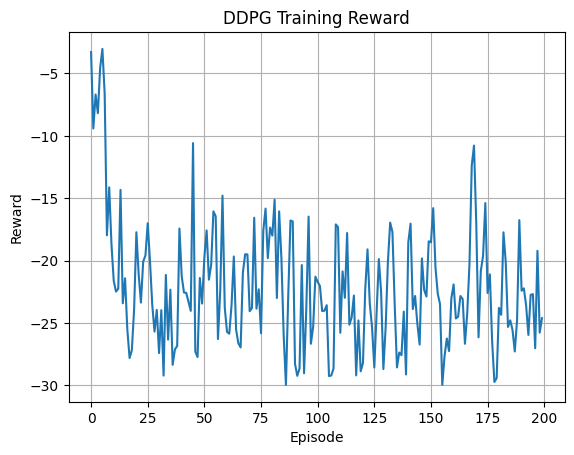

In [37]:
env = DummyPromptEnv()
agent = DDPG(state_dim=env.state_dim, action_dim=env.action_dim)
rewards = []

for ep in range(200):
    state = env.reset()
    total_reward = 0
    for _ in range(20):
        action = agent.select_action(state)
        next_state, reward, done, _ = env.step(action)
        agent.replay_buffer.push(state, action, reward, next_state, float(done))
        agent.update(batch_size=64)
        state = next_state
        total_reward += reward
        if done:
            break
    rewards.append(total_reward)
    if ep % 10 == 0:
        print(f"Episode {ep} | Total Reward: {total_reward:.2f}")

plt.plot(rewards)
plt.title("DDPG Training Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

In [38]:
chat_with_bot(agent, "What is the importance of photosynthesis?")


 Modified Prompt Sent to LLM:
 Please answer in a casual and detailed manner:
What is the importance of photosynthesis?

 LLM Response:
 Dude, photosynthesis is like the ultimate superpower of plants! It's the process by which they convert light energy from the sun into chemical energy in the form of glucose, which they use to fuel their growth, development, and survival. But, let's dive deeper into the awesomeness of photosynthesis and explore its importance.

**Oxygen Production**: Photosynthesis is responsible for producing oxygen as a byproduct. Yes, you heard that right! Plants produce approximately 70-80% of the world's oxygen through photosynthesis. Without it, humans wouldn't be able to breathe. It's literally the air we breathe, bruh!

**Food Production**: Photosynthesis is the primary source of food for countless organisms on our planet. Plants use the energy they produce to synthesize glucose, which serves as food for themselves and other organisms. Herbivores rely on plant

"Dude, photosynthesis is like the ultimate superpower of plants! It's the process by which they convert light energy from the sun into chemical energy in the form of glucose, which they use to fuel their growth, development, and survival. But, let's dive deeper into the awesomeness of photosynthesis and explore its importance.\n\n**Oxygen Production**: Photosynthesis is responsible for producing oxygen as a byproduct. Yes, you heard that right! Plants produce approximately 70-80% of the world's oxygen through photosynthesis. Without it, humans wouldn't be able to breathe. It's literally the air we breathe, bruh!\n\n**Food Production**: Photosynthesis is the primary source of food for countless organisms on our planet. Plants use the energy they produce to synthesize glucose, which serves as food for themselves and other organisms. Herbivores rely on plants as their primary source of food, while omnivores and carnivores rely on plants indirectly through the food chain.\n\n**Energy Sourc

In [34]:
def save_models(agent):
    torch.save(agent.actor.state_dict(), "ddpg_actor.pth")
    torch.save(agent.critic.state_dict(), "ddpg_critic.pth")
    print("Models saved to ddpg_actor.pth and ddpg_critic.pth")

In [35]:
save_models(agent)

Models saved to ddpg_actor.pth and ddpg_critic.pth
